https://mlflow.org/docs/latest/ml/getting-started/quickstart/

https://mlflow.org/docs/latest/ml/tracking/

# Step 1 - Set up MLflow

MLflow is available on PyPI. If you don't already have it installed on your system, you can install it with:

In [ ]:
pip install mlflow

Then, follow the instructions in the <a href="https://mlflow.org/docs/latest/ml/getting-started/running-notebooks/">Set Up MLflow</a> guide to set up MLflow.

If you just want to start super quick, run the following code in a notebook cell:

In [4]:
import mlflow

mlflow.set_experiment("MLflow Quickstart")

2026/09/01 19:23:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/01 19:23:19 INFO mlflow.store.db.utils: Updating database tables
2026/09/01 19:23:21 INFO mlflow.tracking.fluent: Experiment with name 'MLflow Quickstart' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/kiwi/projects/self-learn-codes/student_versions/mlflow_quickstart/mlruns/1', creation_time=1788305001498, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788305001498, lifecycle_stage='active', name='MLflow Quickstart', tags={}, trace_location=None, workspace='default'>

# Step 2 - Prepare training data

Before training our first model, let's prepare the training data and model hyperparameters.

In [5]:
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the Iris dataset
X, y = datasets.load_iris(return_X_y=True)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model hyperparameters
params = {
    "solver":"lbfgs", # Uses the L-BFGS optimization algorithm to find the model coefficients that minimize prediction error
    "max_iter": 1000, 
    "random_state": 8888, # Sets a fixed random seed so randomized behavior can be reproduced. 8888 is arbitrary—using the same seed produces consistent results
}

# Step 3 - Train a model with MLflow Autologging

In this step, we train the model on the training data loaded in the previous step, and log the model and its metadata to MLflow.

The easiest way to do this is to using MLflow's **Autologging** feature.

In [6]:
import mlflow

# Enable autologging for scikit-learn
mlflow.sklearn.autolog()

# Just train the model normally
lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

2026/09/01 19:28:17 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3a525715357a4a689fcef470bf9d0a2c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/01 19:28:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/kiwi/projects/self-learn-codes/student_versions/mlflow_quickstart/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",8888
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

# Step 4 - View the Run in the MLflow UI

To see the results of training, you can access the MLflow UI by navigating to the URL of the Tracking Server.

If you have not started one, open a new terminal and run the following command at the root of the MLflow project and access the UI at http://localhost:5000 (or the port number you specified).

The training **Run** created by MLflow is listed in the table. Click the run to view the details.

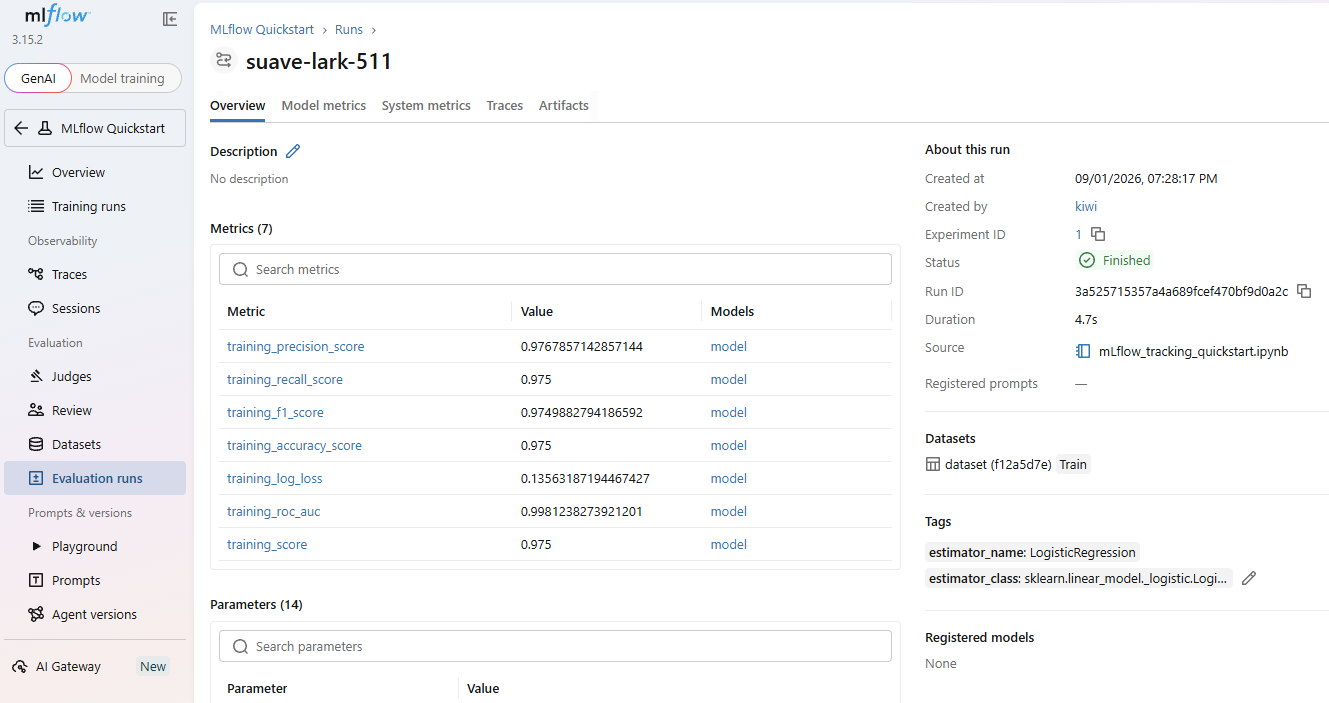

The Run detail page shows an overview of the run, its recorded metrics, hyper-parameters, tags, and more. Play around with the UI to see the different views and features.

Scroll down to the "Model" section and you should see the model that was logged during training. Click on the model to view the details.

The model page displays similar metadata such as performance metrics and hyper-parameters. It also includes an "Artifacts" section that lists the files that were logged during training. You can also see environment information such as the Python version and dependencies, which are stored for reproducibility.

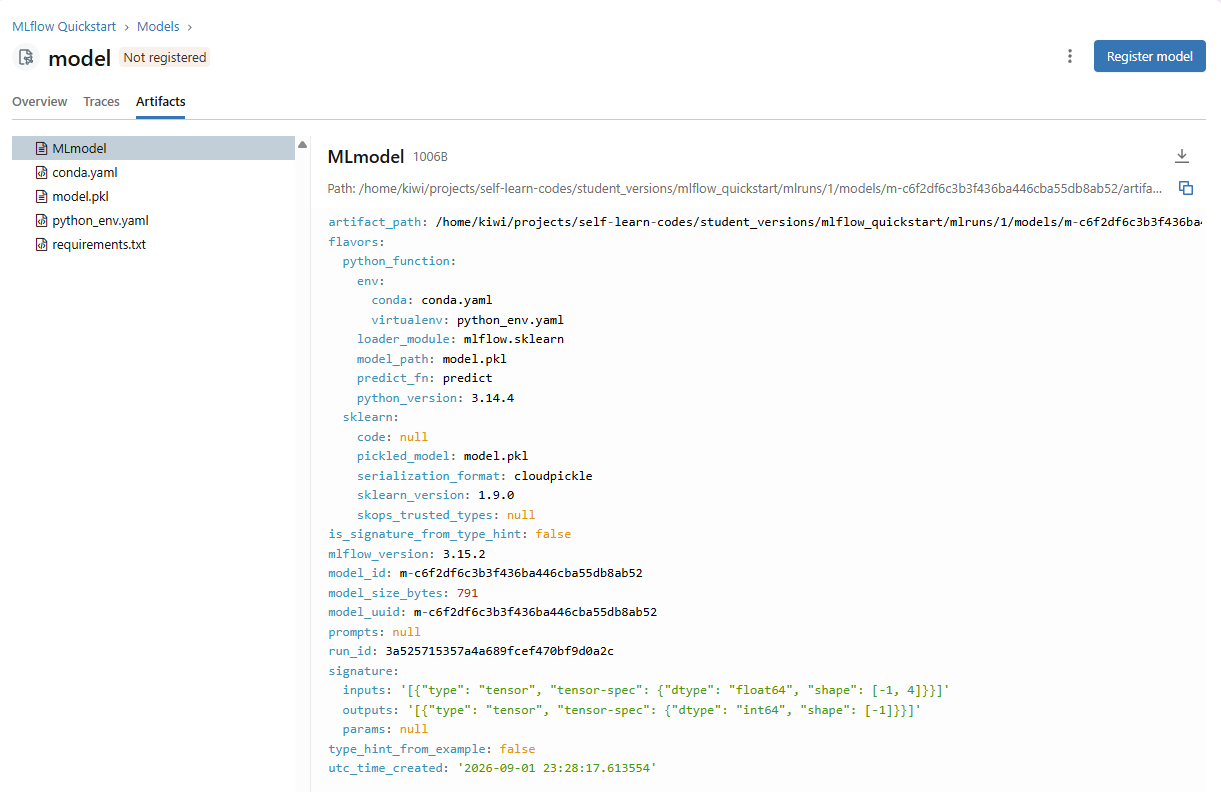

# Step 5 - Log a model and metadata manually

Now that we have learned how to log a model training run with MLflow autologging, let's step further and learn how to log a model and metadata manually. This is useful when you want to have more control over the logging process.

The steps that we will take are:

- Initiate an MLflow **run** context to start a new run that we will log the model and metadata to.
- Train and test the model.
- **Log** model **parameters** and performance **metrics**.
- **Tag** the run for easy retrieval.

In [8]:
# Start an MLflow run

with mlflow.start_run():
    
    # Log the hyperparameters
    mlflow.log_params(params)

    # Train the model
    lr = LogisticRegression(**params)
    lr.fit(X_train, y_train)

    # Log the model
    model_info = mlflow.sklearn.log_model(sk_model=lr, name="iris_model")

    # Predict on the test set, compute and log the loss metric
    y_pred = lr.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric("accuracy", accuracy)

    # Optional: Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "Basic LR model for iris data")

2026/09/01 19:36:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/kiwi/projects/self-learn-codes/student_versions/mlflow_quickstart/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


# Step 6 - Load the model back for inference

After logging the model, we can perform inference by:

- **Loading** the model using MLflow's `pyfunc` flavor.
- Running **Predict** on new data using the loaded model.

To load the model as a native scikit-learn model, use `mlflow.sklearn.load_model(model_info.model_uri)` instead of the pyfunc flavor.

In [10]:
# Load the model back for predictions as a generic Python Function model
loaded_model = mlflow.pyfunc.load_model(model_info.model_uri)

predictions = loaded_model.predict(X_test)

iris_feature_names = datasets.load_iris().feature_names

result = pd.DataFrame(X_test, columns=iris_feature_names)
result["actual_class"] = y_test
result["predicted_class"] = predictions

result[:4]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_class,predicted_class
0,6.1,2.8,4.7,1.2,1,1
1,5.7,3.8,1.7,0.3,0,0
2,7.7,2.6,6.9,2.3,2,2
3,6.0,2.9,4.5,1.5,1,1


# MLflow Tracking

The MLflow Tracking is an API and UI for logging parameters, code versions, metrics, and output files when running your machine learning code and for later visualizing the results.

MLflow Tracking provides Python , REST , R, and Java APIs.

# Concepts

## Runs
MLflow Tracking is organized around the concept of **runs**, which are executions of some piece of data science code, for example, a single `python train.py` execution.

Each run records metadata (various information about your run such as metrics, parameters, start and end times) and artifacts (output files from the run such as model weights, images, etc).

## Models
Models represent the trained machine learning artifacts that are produced during your runs. Logged Models contain their own metadata and artifacts similar to runs.

## Experiments
An experiment groups together runs and models for a specific task. You can create an experiment using the CLI, API, or UI.

The MLflow API and UI also let you create and search for experiments. See <a href="https://mlflow.org/docs/latest/ml/tracking/tracking-api/#experiment-organization">Organizing Runs into Experiments</a> for more details on how to organize your runs into experiments.